# Vertical (FieldList): interpolating from pressure to pressure levels

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

import earthkit.meteo.vertical.fieldlist as vertical

## Getting the data

The input is GRIB data on pressure levels for one step. We fetch the file and extract the temperature fields from it.

In [2]:
fl = ekd.from_source("sample", "tz_pl_global.grib1").to_fieldlist()
t = fl.sel({"parameter.variable": "t"})
t.ls()

tz_pl_global.grib1:   0%|          | 0.00/44.2k [00:00<?, ?B/s]

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1000,pressure,0,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,850,pressure,0,regular_ll
2,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,700,pressure,0,regular_ll
3,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,500,pressure,0,regular_ll
4,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,400,pressure,0,regular_ll
5,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,300,pressure,0,regular_ll
6,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,250,pressure,0,regular_ll
7,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,200,pressure,0,regular_ll
8,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,150,pressure,0,regular_ll
9,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,100,pressure,0,regular_ll


## Using interpolate_monotonic

In [3]:
# extract the coordinates of the input fields
coord = [f.vertical.level(units="Pa") for f in t]  # Pa

# define the target coordinates
target_coords = [87000.0, 35000.0]  # Pa

# define the coordinate type
# (must be an earthkit-data "vertical.level_type")
coord_type = t[0].vertical.level_type()

t_res = vertical.interpolate_monotonic(
    t,  # data to interpolate
    coords=coord,
    target_coords=target_coords,
    coord_type=coord_type,
    interpolation="linear",
)

# list the result
t_res.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,870.0,pressure,0,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,350.0,pressure,0,regular_ll


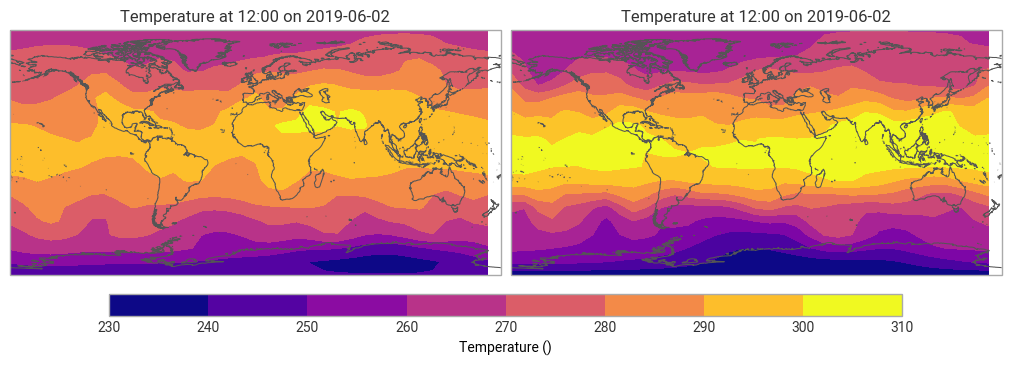

In [4]:
# plot the resulting fields
ekp.quickplot(t_res)

### Interpolating to a pressure field

In [5]:
pres_pv = ekd.from_source("sample", "pressure_on_pv_global.grib1").to_fieldlist()[0]
pres_pv.ls()

pressure_on_pv_global.grib1:   0%|          | 0.00/1.52k [00:00<?, ?B/s]

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,pres,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,2000,potential_vorticity,0,regular_ll


Next, we interpolate the data to the target field.

In [6]:
t_res_pv = vertical.interpolate_monotonic(
    t,
    coords=coord,
    target_coords=pres_pv,
    coord_type=coord_type,
    interpolation="linear",
)

t_res_pv.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,323.655547,pressure,0,regular_ll


Finally, plot the pressure of the 2 PVU potential vorticity level and the temperature interpolated to it side by side.

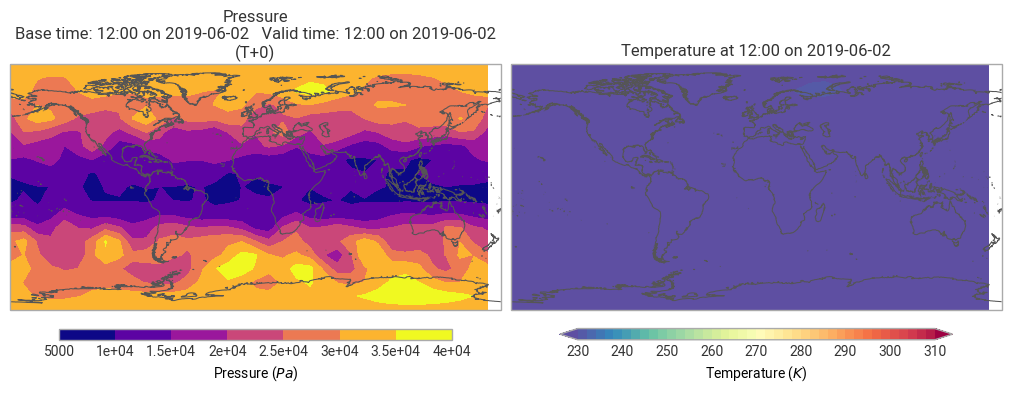

In [7]:
ekp.quickplot(ekd.FieldList.from_fields([pres_pv, t_res_pv]))

## Writing to GRIB

In [8]:
# write to GRIB file
t_res.to_target("file", "_pl_to_pl.grib")

# read back and check saved GRIB data
ekd.from_source("file", "_pl_to_pl.grib").to_fieldlist().ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,870,pressure,0,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,350,pressure,0,regular_ll
